# HBT / $g^{(2)}$ Analysis — Tutorial

This notebook is a **hands-on guide** to the second-order correlation (HBT) analysis pipeline used for
the High-Harmonic Generation (HHG) experiments. It explains, step by step:

1. what is actually stored inside the `.pkl` files (with a full structure dump),
2. the crucial distinction between **physical** and **virtual** data,
3. how each quantity ($g^{(2)}$ direct / delay / heralded, and the Cauchy–Schwarz $R$) is computed and **from which key**,
4. how the visualisation auto-fills titles/legends from the metadata.

The engine lives in two modules:
* `src/hbt_core.py` — `HBTMeasurement`: loads a run, exposes the data and computes the metrics.
* `src/hbt_visu.py` — `GridVisualizer`: builds the coherence / $g^{(2)}$ / $R$ figures.

## 0. Setup

In [1]:
import numpy as np
from pathlib import Path

from src.hbt_core import HBTMeasurement
from src.hbt_visu import GridVisualizer

## 1. The datasets

The June-12 campaign contains four runs that differ by **bandpass filter** (700/10 nm vs 700/40 nm)
and **polarisation** (no polariser vs polariser *P1*). Everything else (sample, laser, rep-rate) is identical,
so they are ideal for a side-by-side comparison.

In [2]:
base_dir = Path("data/Jun12")

paths = {
    "700-10 (No Pol)": base_dir / "700-10 no P1 2026-06-12_17-36-40_g2_heralded_virtual" / "17-36-40_2026-06-12_40.7mW_num0_chunk0.pkl",
    "700-10 (Pol 1)":  base_dir / "700-10 P1 2026-06-12_17-10-59_g2_heralded_virtual"    / "17-10-59_2026-06-12_40.7mW_num0_chunk0.pkl",
    "700-40 (No Pol)": base_dir / "700-40 no P1 2026-06-12_17-30-07_g2_heralded_virtual" / "17-30-07_2026-06-12_40.7mW_num0_chunk0.pkl",
    "700-40 (Pol 1)":  base_dir / "700-40 P1 2026-06-12_17-26-52_g2_heralded_virtual"    / "17-26-52_2026-06-12_40.7mW_num0_chunk0.pkl",
}

# Load one run to explore (the metadata JSON next to the pkl is read automatically).
run = HBTMeasurement(paths["700-10 (No Pol)"])
print("Loaded:", run.short_tag())

Loaded: 700/10 nm | No pol. | 40.7 mW


## 2. Look inside the raw `.pkl`

Before processing anything, it is worth **seeing exactly what the file contains**. `HBTMeasurement.describe()`
walks the whole pickle and prints every key with its type, array length (and a short preview) or scalar value.

In [3]:
run.describe(max_depth=4)

PKL FILE : 17-36-40_2026-06-12_40.7mW_num0_chunk0.pkl
FOLDER   : 700-10 no P1 2026-06-12_17-36-40_g2_heralded_virtual
top-level keys: ['Parameters', 'data']
Parameters/  (dict, 2 keys)
    general/  (dict, 8 keys)
        date: str = '2026-06-12'
        time: str = '17-36-40'
        experiment_type: str = 'g2_heralded_virtual'
        save_dir: str = 'C:\\Users\\QUANTUM\\OneDrive - ENSTA\\!Working files\\HBT\\HBT Data\\Tests_Jun\\2026-06-12_17-36-40_g2_heralded_virtual'
        material: str = 'CdTe110'
        laser/  (dict, 2 keys)
            rep_rate_hz: float = 18880000.0
            wavelength_nm: int = 2100
        timetagging/  (dict, 10 keys)
            tt_mode: str = 'Standard'
            binwidth_ps: int = 100
            num_bins: int = 50000
            channels: list[6]  (1, 2, 3, 4, ...)
            mode_on_channel: list[6]  (H3T, H3R, H4T, H4R, ...)
            deadtime: list[6]  (0, 0, 0, 0, ...)
            delays: list[6]  (0, -1000, 20000, 16500, ...)
          

## 3. Physical vs virtual — the data model (the big idea)

Each harmonic $H_n$ is sent onto a **beamsplitter** and detected on **two physical detectors**:
a *Transmitted* (`HnT`) and a *Reflected* (`HnR`) arm. So:

| Detector | 1 | 2 | 3 | 4 | 5 | 6 |
|----------|----|----|----|----|----|----|
| Mode     | H3T | H3R | H4T | H4R | H5T | H5R |

A **virtual** channel $H_n$ is the *merged* (T + R) click stream of one harmonic.

What the pickle stores is **not symmetric** between the two worlds:

| Quantity | Physical (per detector) | Virtual (merged harmonic) |
|---|---|---|
| Singles | `counts_physical`, `countrates_physical` | `counts_virtual`, `countrates_virtual` |
| Two-fold coincidences (scalar) | `coincidences_twofold_physical` (15 pairs) | `coincidences_twofold_virtual` (3 pairs) |
| Full $g^{(2)}(\tau)$ **histogram** |  **not recorded** |  `correlations_virtual` |
| Three-fold heralded | — | `heralded_threefold` |

**Consequence — and the "fallback" story.**
An earlier version of the code asked for a *physical histogram*, didn't find one, and **silently substituted the
virtual histogram**. That is wrong for two reasons:

* the virtual **auto**-correlation $(H_n,H_n)$ correlates a stream *with itself*, producing a huge non-physical
  self-coincidence spike at exactly $\tau = 0$ → fake "super-bunching" ($g^{(2)}\approx 3$ instead of $\approx 0.35$);
* every T/R combination collapses onto the *same* virtual histogram, so the T/R information is lost.

The pipeline now routes the data **explicitly, with no silent fallback**:

* **Physical $g^{(2)}$** is computed from the **scalar** physical coincidences (`compute_g2_direct`) → artifact-free, default.
* **Histogram methods** (`compute_g2_delay`, coherence plots) read the **virtual** histograms and are clearly labelled *virtual*;
  asking `get_correlation_trace(..., is_virtual=False)` returns `None` rather than faking it.
* For virtual **auto** histograms, the single $\tau=0$ self-coincidence bin is replaced by its neighbours' mean.

## 4. Channels, harmonics & metadata

The driving laser is at 2100 nm, so $H_3, H_4, H_5$ sit near 700, 525, 420 nm.
`channel_map` and `get_ch` translate between detector numbers and physical names, and a set of
helper attributes expose the metadata used to label the plots.

In [4]:
print("channel_map :", run.channel_map)
print("get_ch('H3T'):", run.get_ch("H3T"), "| get_ch('H4R'):", run.get_ch("H4R"))
print()
print("material            :", run.material)
print("wavelength_nm       :", run.wavelength_nm)
print("power_mw            :", run.power_mw)
print("rep_rate_hz         :", run.rep_rate_hz, "  -> rep_period_ns =", round(run.rep_period_ns, 3))
print("binwidth_ps         :", run.binwidth_ps)
print("coincidence_window  :", run.coincidence_window_ns, "ns")
print("duration_s          :", run.duration_s)
print("filter_label        :", run.filter_label)
print("polarization        :", run.polarization)
print()
print("acquisition_summary :", run.acquisition_summary())
print("acquisition_details :", run.acquisition_details())
print("short_tag           :", run.short_tag())

channel_map : {1: 'H3T', 2: 'H3R', 3: 'H4T', 4: 'H4R', 5: 'H5T', 6: 'H5R'}
get_ch('H3T'): 1 | get_ch('H4R'): 4

material            : CdTe110
wavelength_nm       : 2100
power_mw            : 40.7
rep_rate_hz         : 18880000.0   -> rep_period_ns = 52.966
binwidth_ps         : 100.0
coincidence_window  : 25.0 ns
duration_s          : 60.0
filter_label        : 700/10 nm
polarization        : No pol.

acquisition_summary : Sample: CdTe110  |  $\lambda_L = 2100$ nm  |  $P = 40.7$ mW  |  $f_{rep} = 18.88$ MHz  |  Filter: 700/10 nm  |  No pol.
acquisition_details : bin $= 100$ ps  |  coinc. window $= 25$ ns  |  $T_{acq} = 60$ s  |  stage $= 292$  |  2026-06-12
short_tag           : 700/10 nm | No pol. | 40.7 mW


## 5. Building blocks: singles, coincidences, pulses

Three ingredients feed every $g^{(2)}$:

* **Singles** $N_i$ — total clicks on a detector: `_get_counts(c)` → `counts_physical[str(c)]`.
* **Two-fold coincidences** $N_{12}$ — `_get_twofold_coincidence(c1, c2)` → `coincidences_twofold_physical['(c1,c2)']`.
* **Number of laser pulses** $N_\mathrm{pulse} = T_\mathrm{acq}\,f_\mathrm{rep}$ (from `experimental.duration` and `laser.rep_rate_hz`).

In [5]:
c1, c2 = run.get_ch("H3T"), run.get_ch("H3R")   # the physical HBT pair of harmonic H3

N1 = run._get_counts(c1)
N2 = run._get_counts(c2)
N12 = run._get_twofold_coincidence(c1, c2)
N_pulse = (run.duration * 1e-12) * run.rep_rate_hz

print(f"N1  (H3T singles)        = {N1:,.0f}")
print(f"N2  (H3R singles)        = {N2:,.0f}")
print(f"N12 (H3T-H3R coinc.)     = {N12:,.0f}")
print(f"N_pulse                  = {N_pulse:,.0f}")

N1  (H3T singles)        = 164,076,381
N2  (H3R singles)        = 316,369,254
N12 (H3T-H3R coinc.)     = 16,060,563
N_pulse                  = 1,132,800,000


## 6. Physical $g^{(2)}(0)$: the *direct* method (default)

$$ g^{(2)}(0) \;=\; \frac{N_\mathrm{pulse}\,N_{12}}{N_1\,N_2} $$

i.e. the measured coincidences divided by the accidental coincidences expected from uncorrelated singles.
It uses only the **scalar physical** keys, so it is free of the self-correlation artifact and is the default method.

> It does not depend on the integration window `tau_in_ns` (the coincidence window is fixed at acquisition),
> which is why it appears as a flat line on a $\tau$-sweep.

Notice below that the three T/R variants of a cross-correlation now give **distinct** values — proof the physical
detector information is preserved (it used to collapse to a single number).

In [6]:
def g2(name1, name2):
    return run.compute_g2_direct(run.get_ch(name1), run.get_ch(name2))

# manual replication of the formula for the H3 auto-correlation
print("manual    g2(H3 auto) =", round(N_pulse * N12 / (N1 * N2), 4))
print("compute_g2_direct     =", round(g2("H3T", "H3R"), 4))
print()
print("Auto-correlations (HBT of each harmonic):")
for h in ("3", "4", "5"):
    print(f"  H{h}  ({h}T x {h}R): g2 = {g2(f'H{h}T', f'H{h}R'):.4f}")
print()
print("Cross H3-H4, the four physical T/R pairs (now all different):")
for a in ("H3T", "H3R"):
    for b in ("H4T", "H4R"):
        print(f"  {a} x {b}: g2 = {g2(a, b):.4f}")

manual    g2(H3 auto) = 0.3505
compute_g2_direct     = 0.3505

Auto-correlations (HBT of each harmonic):
  H3  (3T x 3R): g2 = 0.3505
  H4  (4T x 4R): g2 = 0.3453
  H5  (5T x 5R): g2 = 0.3882

Cross H3-H4, the four physical T/R pairs (now all different):
  H3T x H4T: g2 = 0.3375
  H3T x H4R: g2 = 0.3362
  H3R x H4T: g2 = 0.3318
  H3R x H4R: g2 = 0.3308


## 7. Virtual histogram methods: delay, heralded, $t_0$ and the artifact

These use the **virtual** $g^{(2)}(\tau)$ histograms (the only histograms present).

* `get_correlation_trace(c1, c2)` returns `(tau_ns, counts)` from `correlations_virtual`
  (`time_bins` are converted ps → ns). For auto pairs the $\tau=0$ self-coincidence spike is suppressed.
* `calculate_t0_shift` finds the centroid of the central peak (absorbs residual delay).
  The repetition period is taken straight from the metadata (`rep_period_ns`) — **no peak-finding/estimation needed**.
* `compute_g2_delay` = central-peak area / mean side-peak area (pulsed area-ratio).
* `compute_g2_heralded` = $N_\mathrm{pulse} N_{12}/(N_1 N_2)$ using the **virtual** histogram peak and virtual singles.

In [7]:
ch1, ch2 = run.get_ch("H3T"), run.get_ch("H3R")

# --- the self-correlation artifact, before/after suppression ---
raw = run.data['correlations_virtual']['(H3,H3)']
tb = np.array(raw['time_bins']) * 1e-3
cnt = np.array(raw['counts'])
i0 = int(np.argmin(np.abs(tb)))
x, y = run.get_correlation_trace(ch1, ch2)   # suppressed (auto pair)
print("Virtual (H3,H3) auto-correlation around tau = 0:")
print(f"  raw zero-lag bin     = {cnt[i0]:,.0f}   (neighbours ~ {cnt[i0-1]:,.0f} / {cnt[i0+1]:,.0f})")
print(f"  after suppression    = {y[i0]:,.0f}")
print()

# --- t0 and the two virtual methods ---
print("rep_period_ns (from metadata):", round(run.rep_period_ns, 3))
print("t0 shift  H3-H4              :", round(run.calculate_t0_shift(run.get_ch('H3T'), run.get_ch('H4T')), 3), "ns")
print("delay     g2(H3-H4) [virtual]:", round(run.compute_g2_delay(run.get_ch('H3T'), run.get_ch('H4T'), 5.0), 4))
print("heralded  g2(H3-H4) [virtual]:", round(run.compute_g2_heralded(run.get_ch('H3T'), run.get_ch('H4T'), 5.0), 4))

Virtual (H3,H3) auto-correlation around tau = 0:
  raw zero-lag bin     = 114,196,742   (neighbours ~ 4,757,688 / 3,803,105)
  after suppression    = 4,280,396

rep_period_ns (from metadata): 52.966
t0 shift  H3-H4              : 5.935 ns
delay     g2(H3-H4) [virtual]: 1.1548
heralded  g2(H3-H4) [virtual]: 0.1702


## 8. Cauchy–Schwarz parameter $R$

$$ R \;=\; \frac{\big[g^{(2)}_{\mathrm{cross}}\big]^2}{g^{(2)}_{\mathrm{auto},1}\;g^{(2)}_{\mathrm{auto},2}} $$

$R > 1$ violates the classical Cauchy–Schwarz inequality. Built from the **physical** (direct) $g^{(2)}$ it is
a genuine non-classicality witness for the cross-correlation between two harmonics.

In [8]:
g2_cross = run.compute_g2_direct(run.get_ch("H3T"), run.get_ch("H4T"))
g2_autoA = run.compute_g2_direct(run.get_ch("H3T"), run.get_ch("H3R"))
g2_autoB = run.compute_g2_direct(run.get_ch("H4T"), run.get_ch("H4R"))
R = run.compute_R_parameter(g2_cross, g2_autoA, g2_autoB)
print(f"g2_cross(H3,H4) = {g2_cross:.4f}")
print(f"g2_auto(H3)     = {g2_autoA:.4f}")
print(f"g2_auto(H4)     = {g2_autoB:.4f}")
print(f"R_34 (TT)       = {R:.4f}")

g2_cross(H3,H4) = 0.3375
g2_auto(H3)     = 0.3505
g2_auto(H4)     = 0.3453
R_34 (TT)       = 0.9409


## 9. Visualisation (titles auto-filled from metadata)

`GridVisualizer` reads the metadata to build informative titles and legends automatically.
With a single run the title carries the full configuration; with several runs each curve is auto-labelled
`filter | polarisation | power`.

Pass `c1, c2` for a single pair, or nothing for the full master grid. `methods=['direct']` keeps the analysis
**physical**; add `'delay'`/`'heralded'` only as virtual cross-checks.

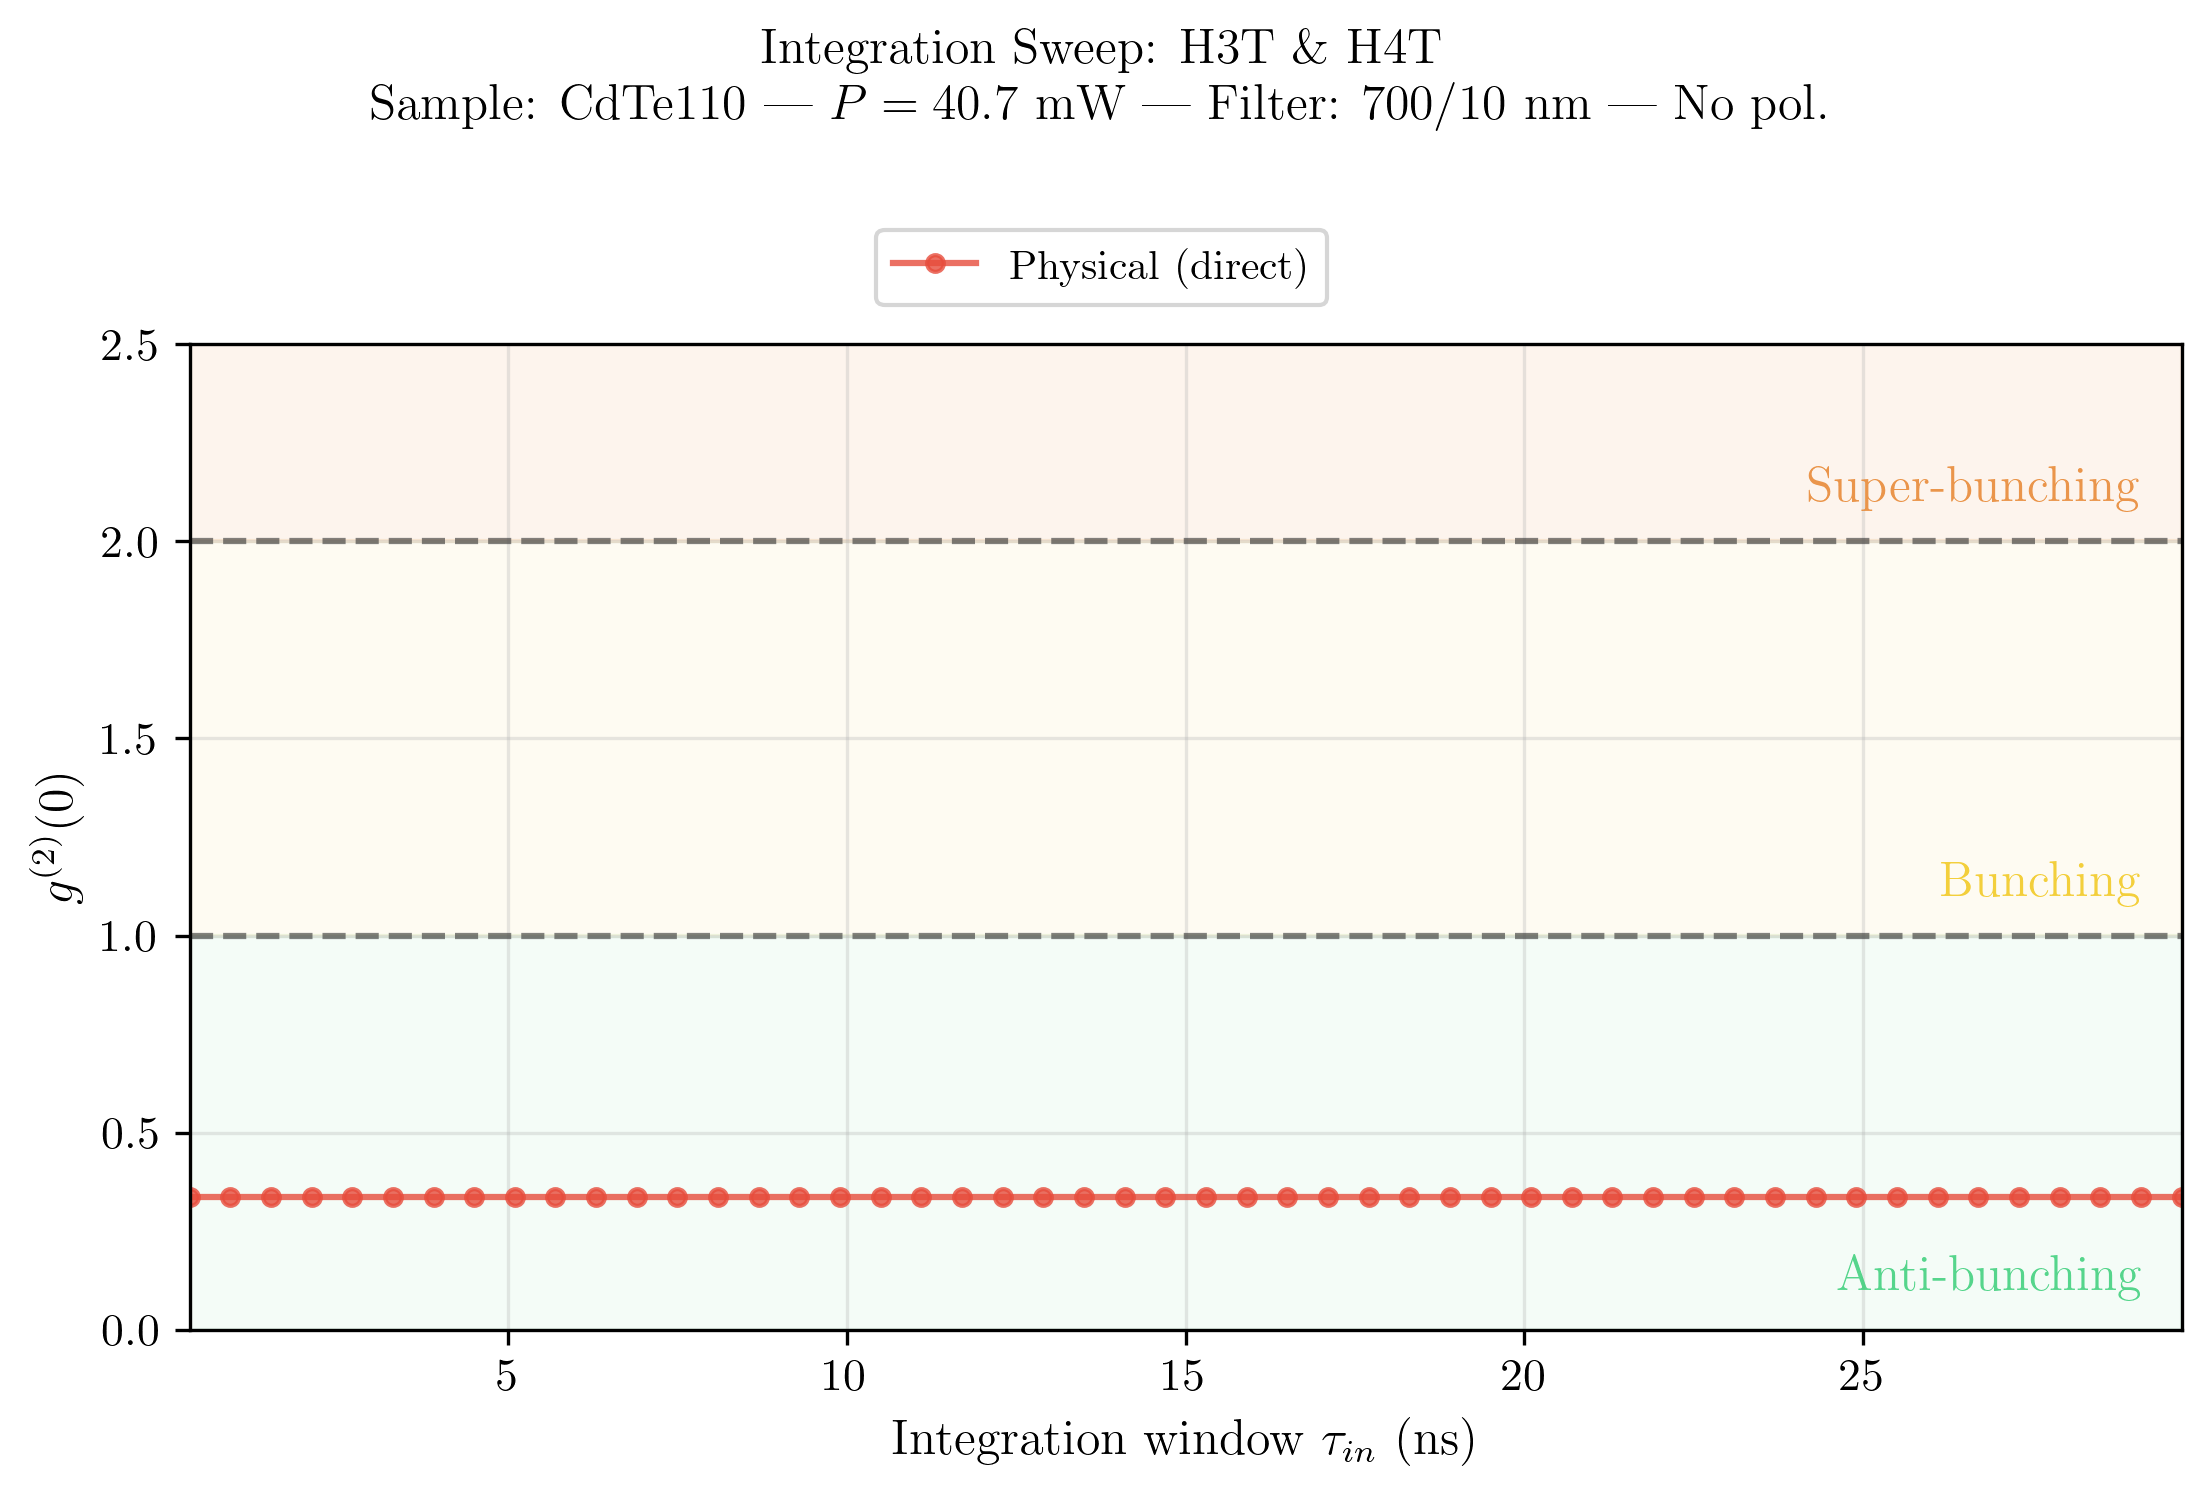

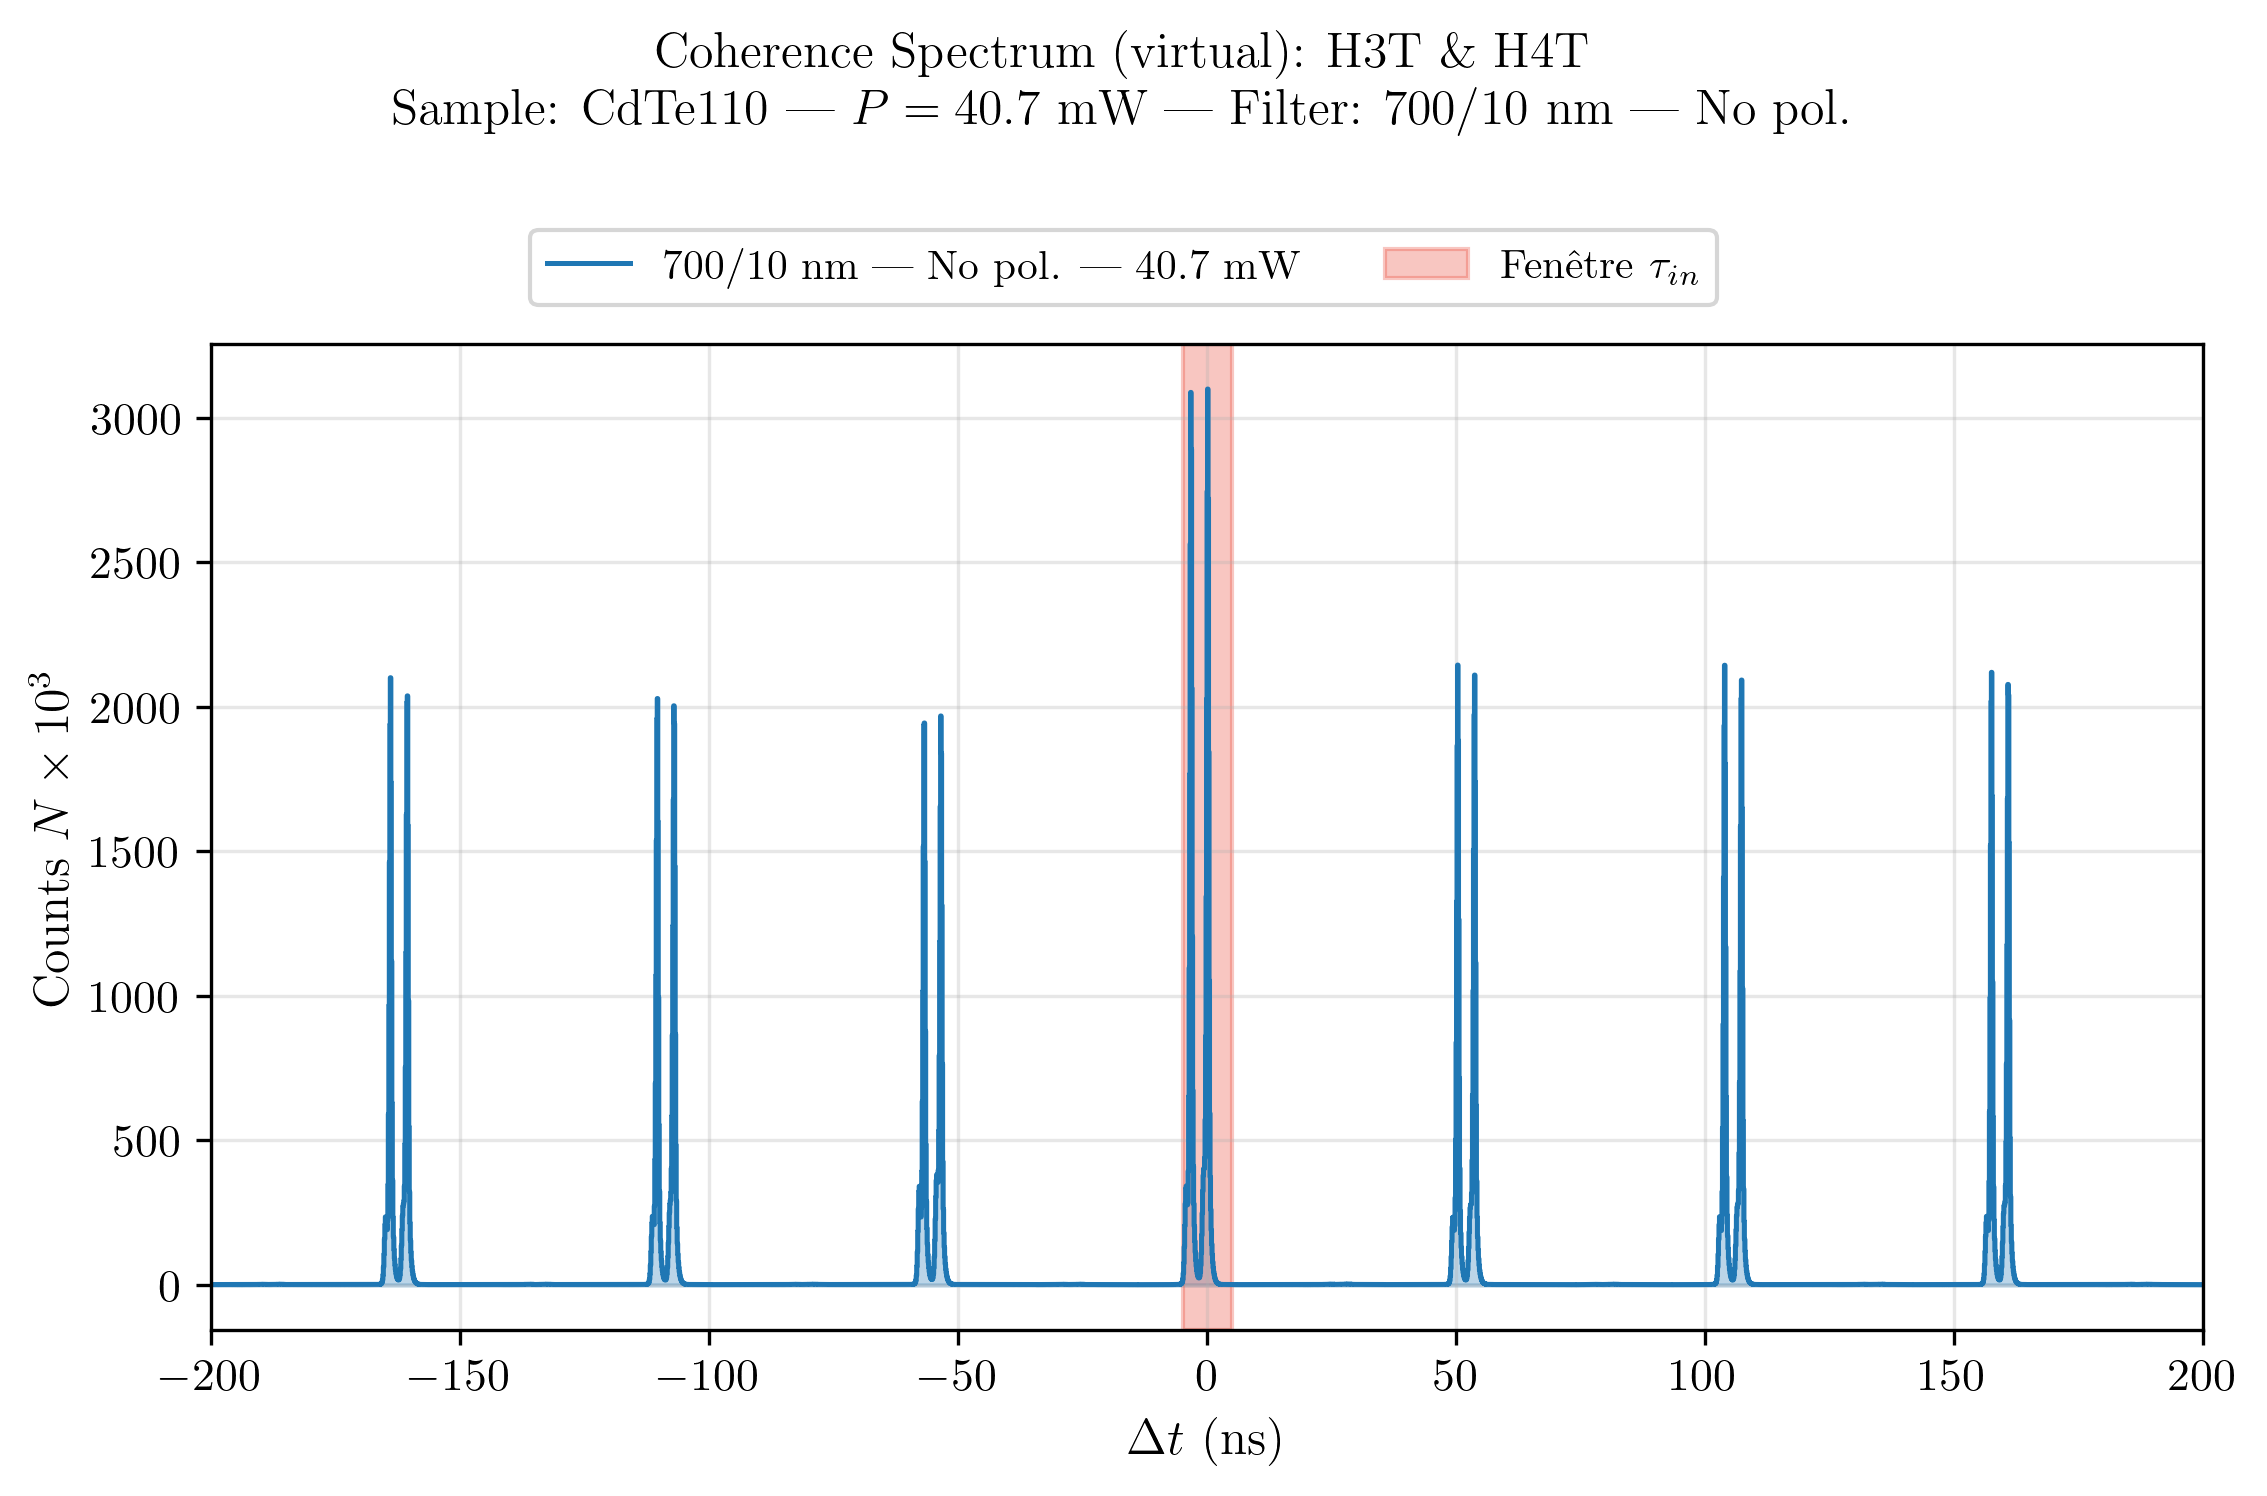

(<Figure size 2400x1500 with 1 Axes>,
 <Axes: xlabel='$\\Delta t$ (ns)', ylabel='Counts $N \\times 10^3$'>)

In [9]:
visu = GridVisualizer(run)   # no label -> title/legend come from the metadata

# single physical g2 sweep for the H3-H4 (TT) cross-correlation
visu.plot_g2(run.get_ch("H3T"), run.get_ch("H4T"), methods=['direct'])

# coherence histogram (virtual, the only one available) for the same pair
visu.plot_coherence(run.get_ch("H3T"), run.get_ch("H4T"), xlim=200, integration_window_ns=10)

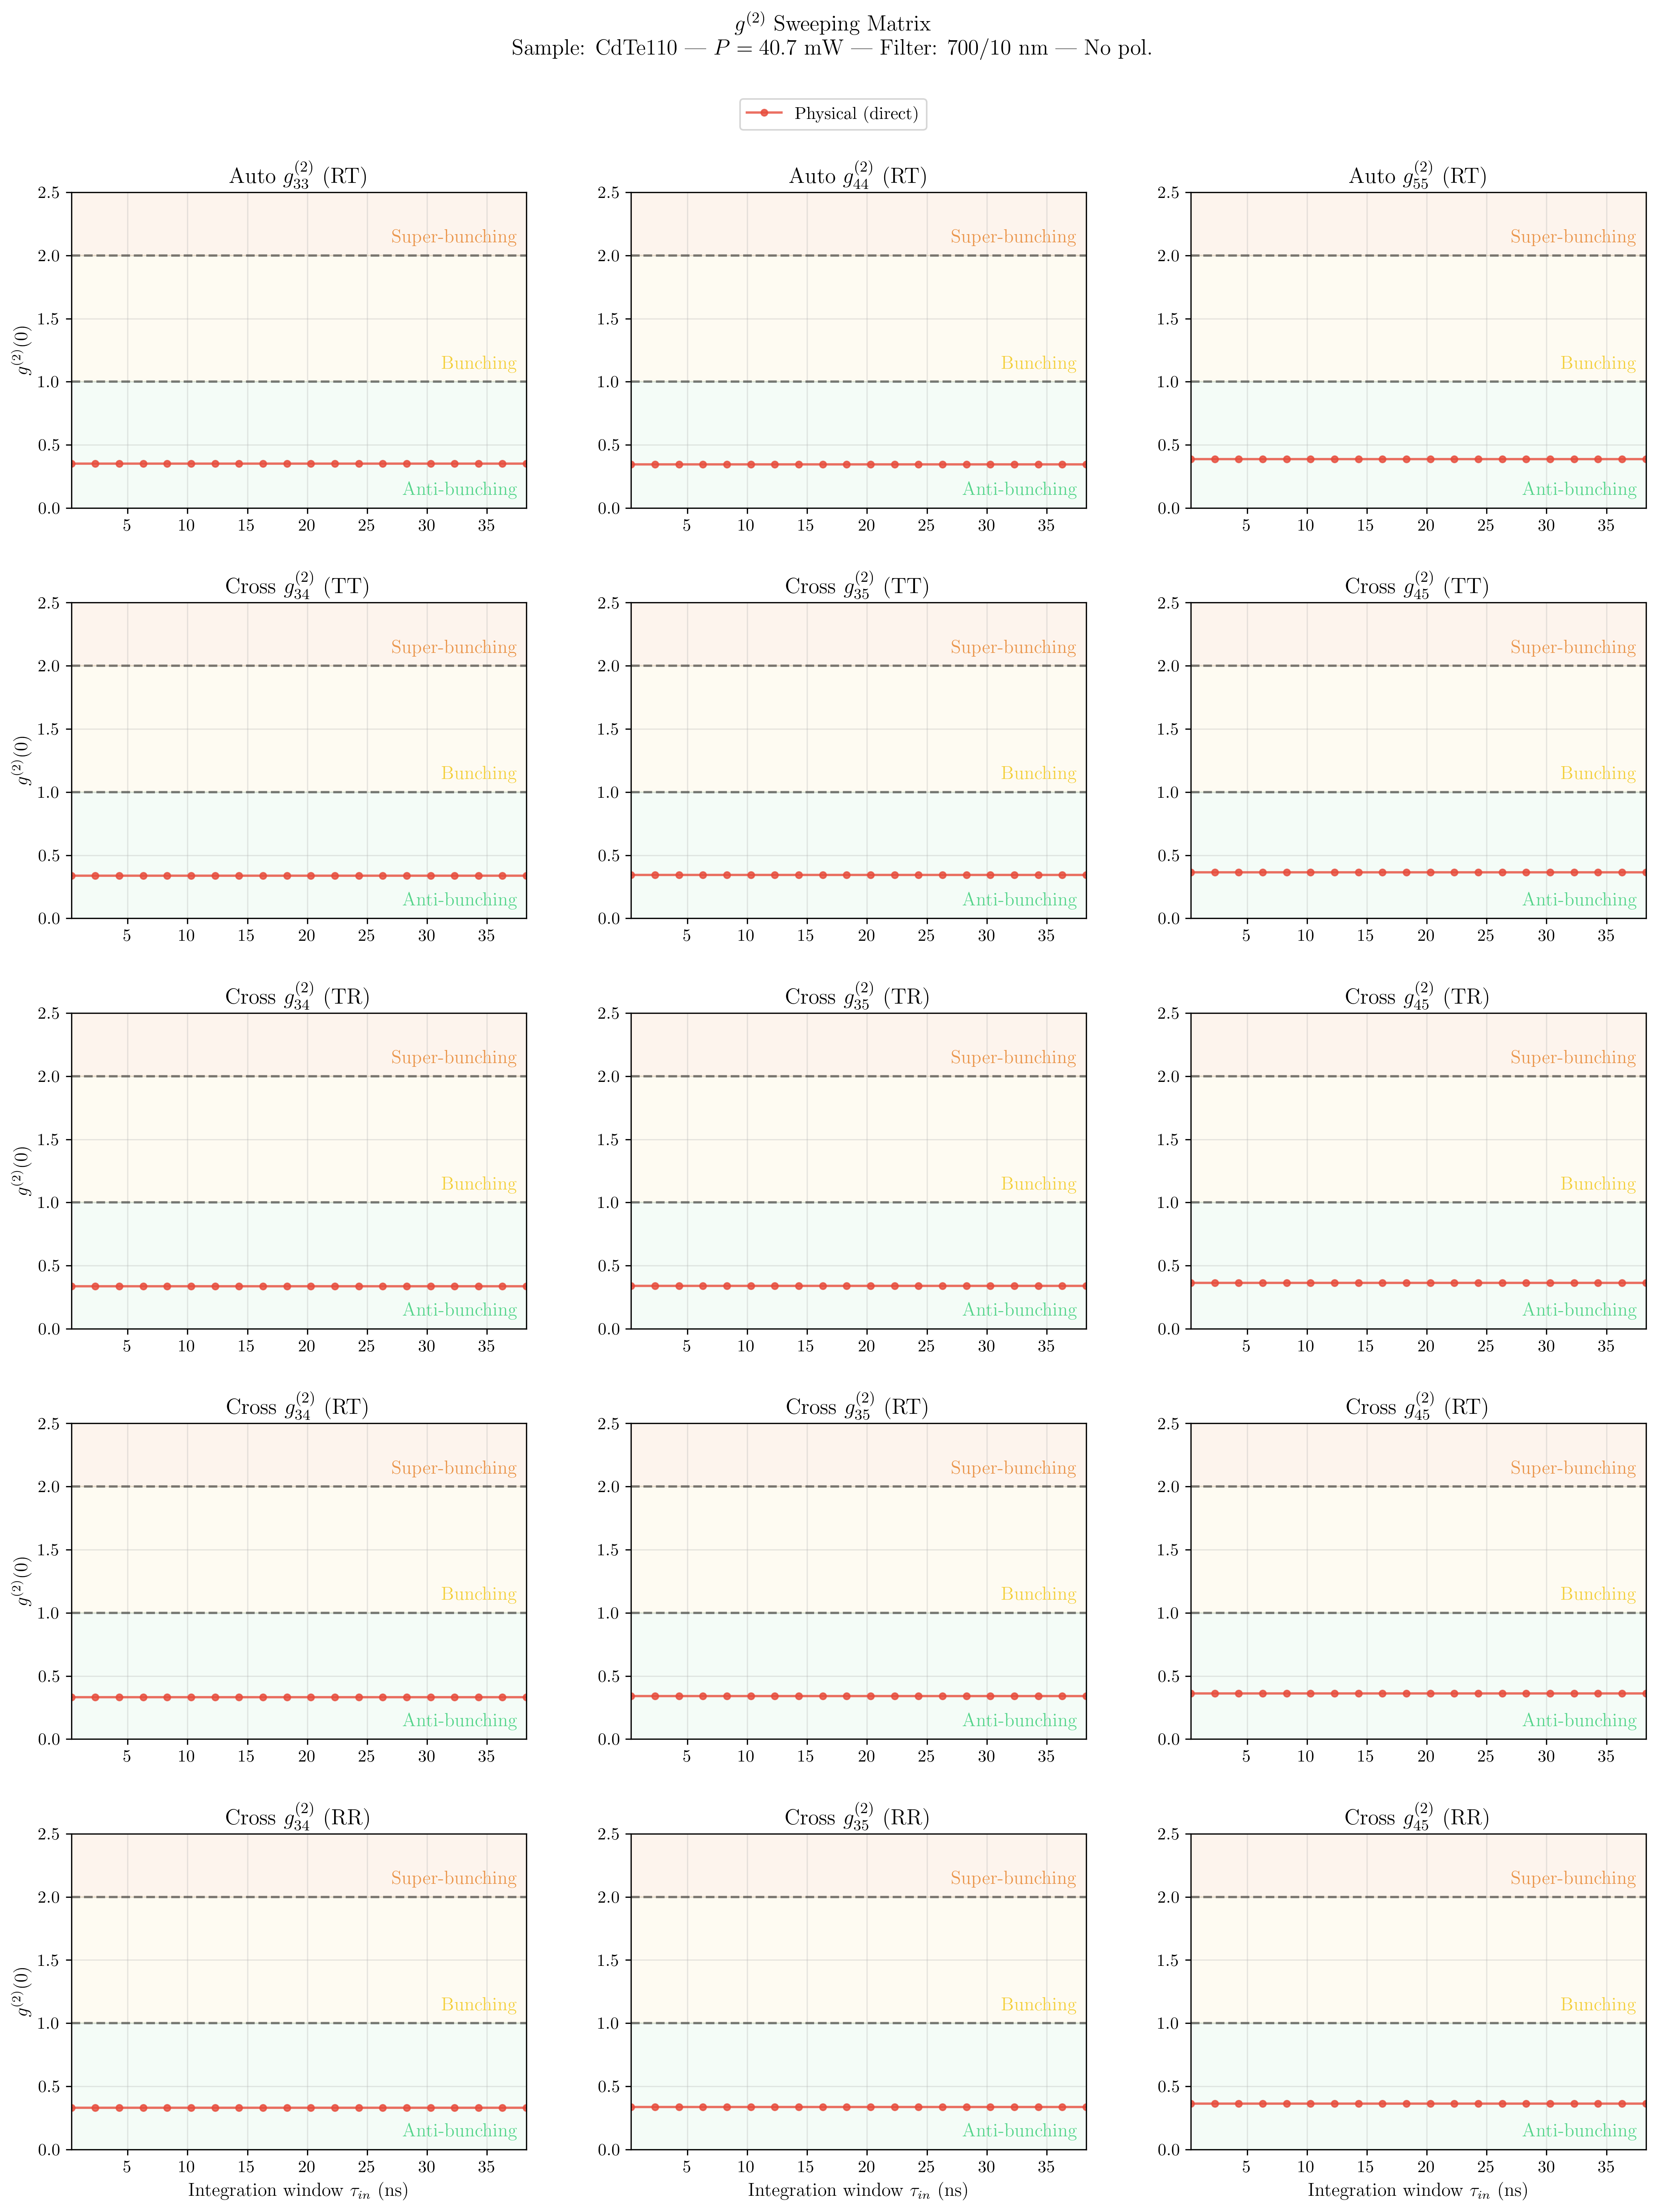

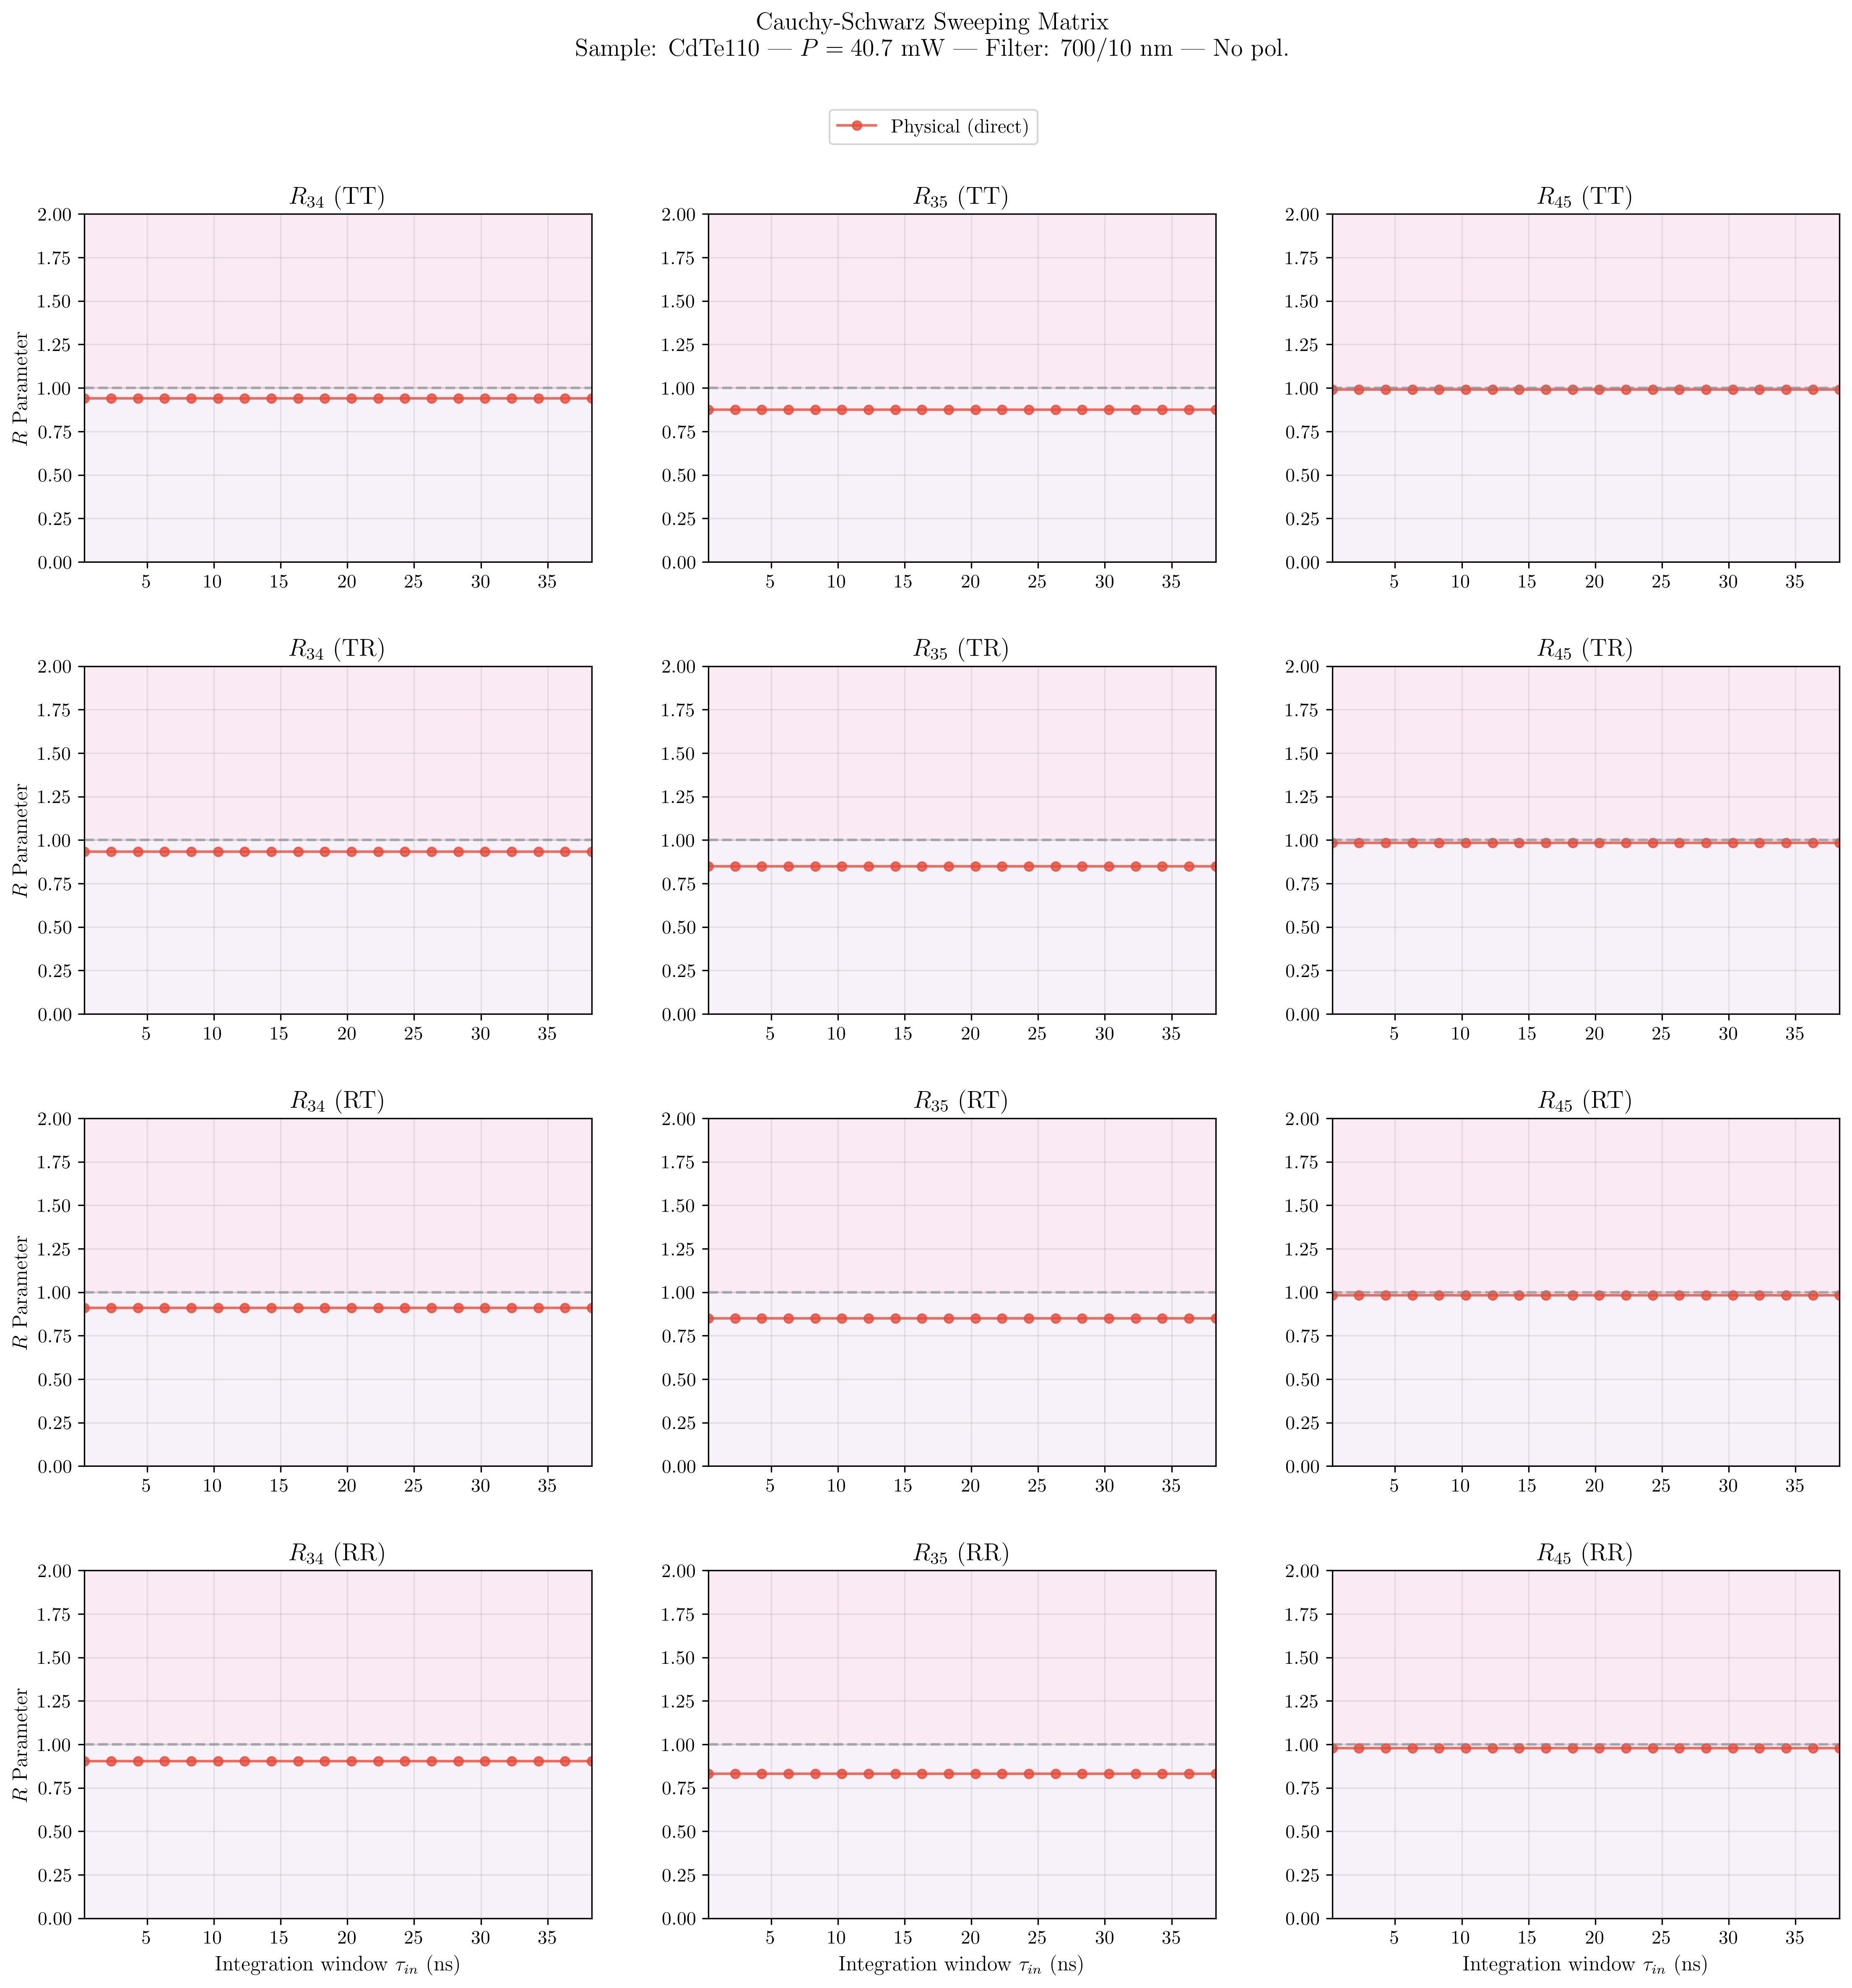

(<Figure size 5400x4800 with 12 Axes>,
 array([[<Axes: title={'center': '$R_{34}$ (TT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TT)'}>,
         <Axes: title={'center': '$R_{45}$ (TT)'}>],
        [<Axes: title={'center': '$R_{34}$ (TR)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TR)'}>,
         <Axes: title={'center': '$R_{45}$ (TR)'}>],
        [<Axes: title={'center': '$R_{34}$ (RT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RT)'}>,
         <Axes: title={'center': '$R_{45}$ (RT)'}>],
        [<Axes: title={'center': '$R_{34}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)', ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)'>,
         <Axes: title={'center': '$R_{45}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)'>]],
       dtype=object))

In [10]:
# Full master grids for this single run (physical g2 and Cauchy-Schwarz R).
visu.plot_g2(methods=['direct'], tau_min=0.3, tau_max=40.0, step=2.0)
visu.plot_R(methods=['direct'], tau_min=0.3, tau_max=40.0, step=2.0)

## 10. Comparing filters & polarisations

Load all four runs and let the comparator overlay them. Because no explicit labels are given, every dataset is
tagged automatically from its own metadata, so the legend reads e.g. `700/10 nm | Pol. P1 | 40.7 mW`.

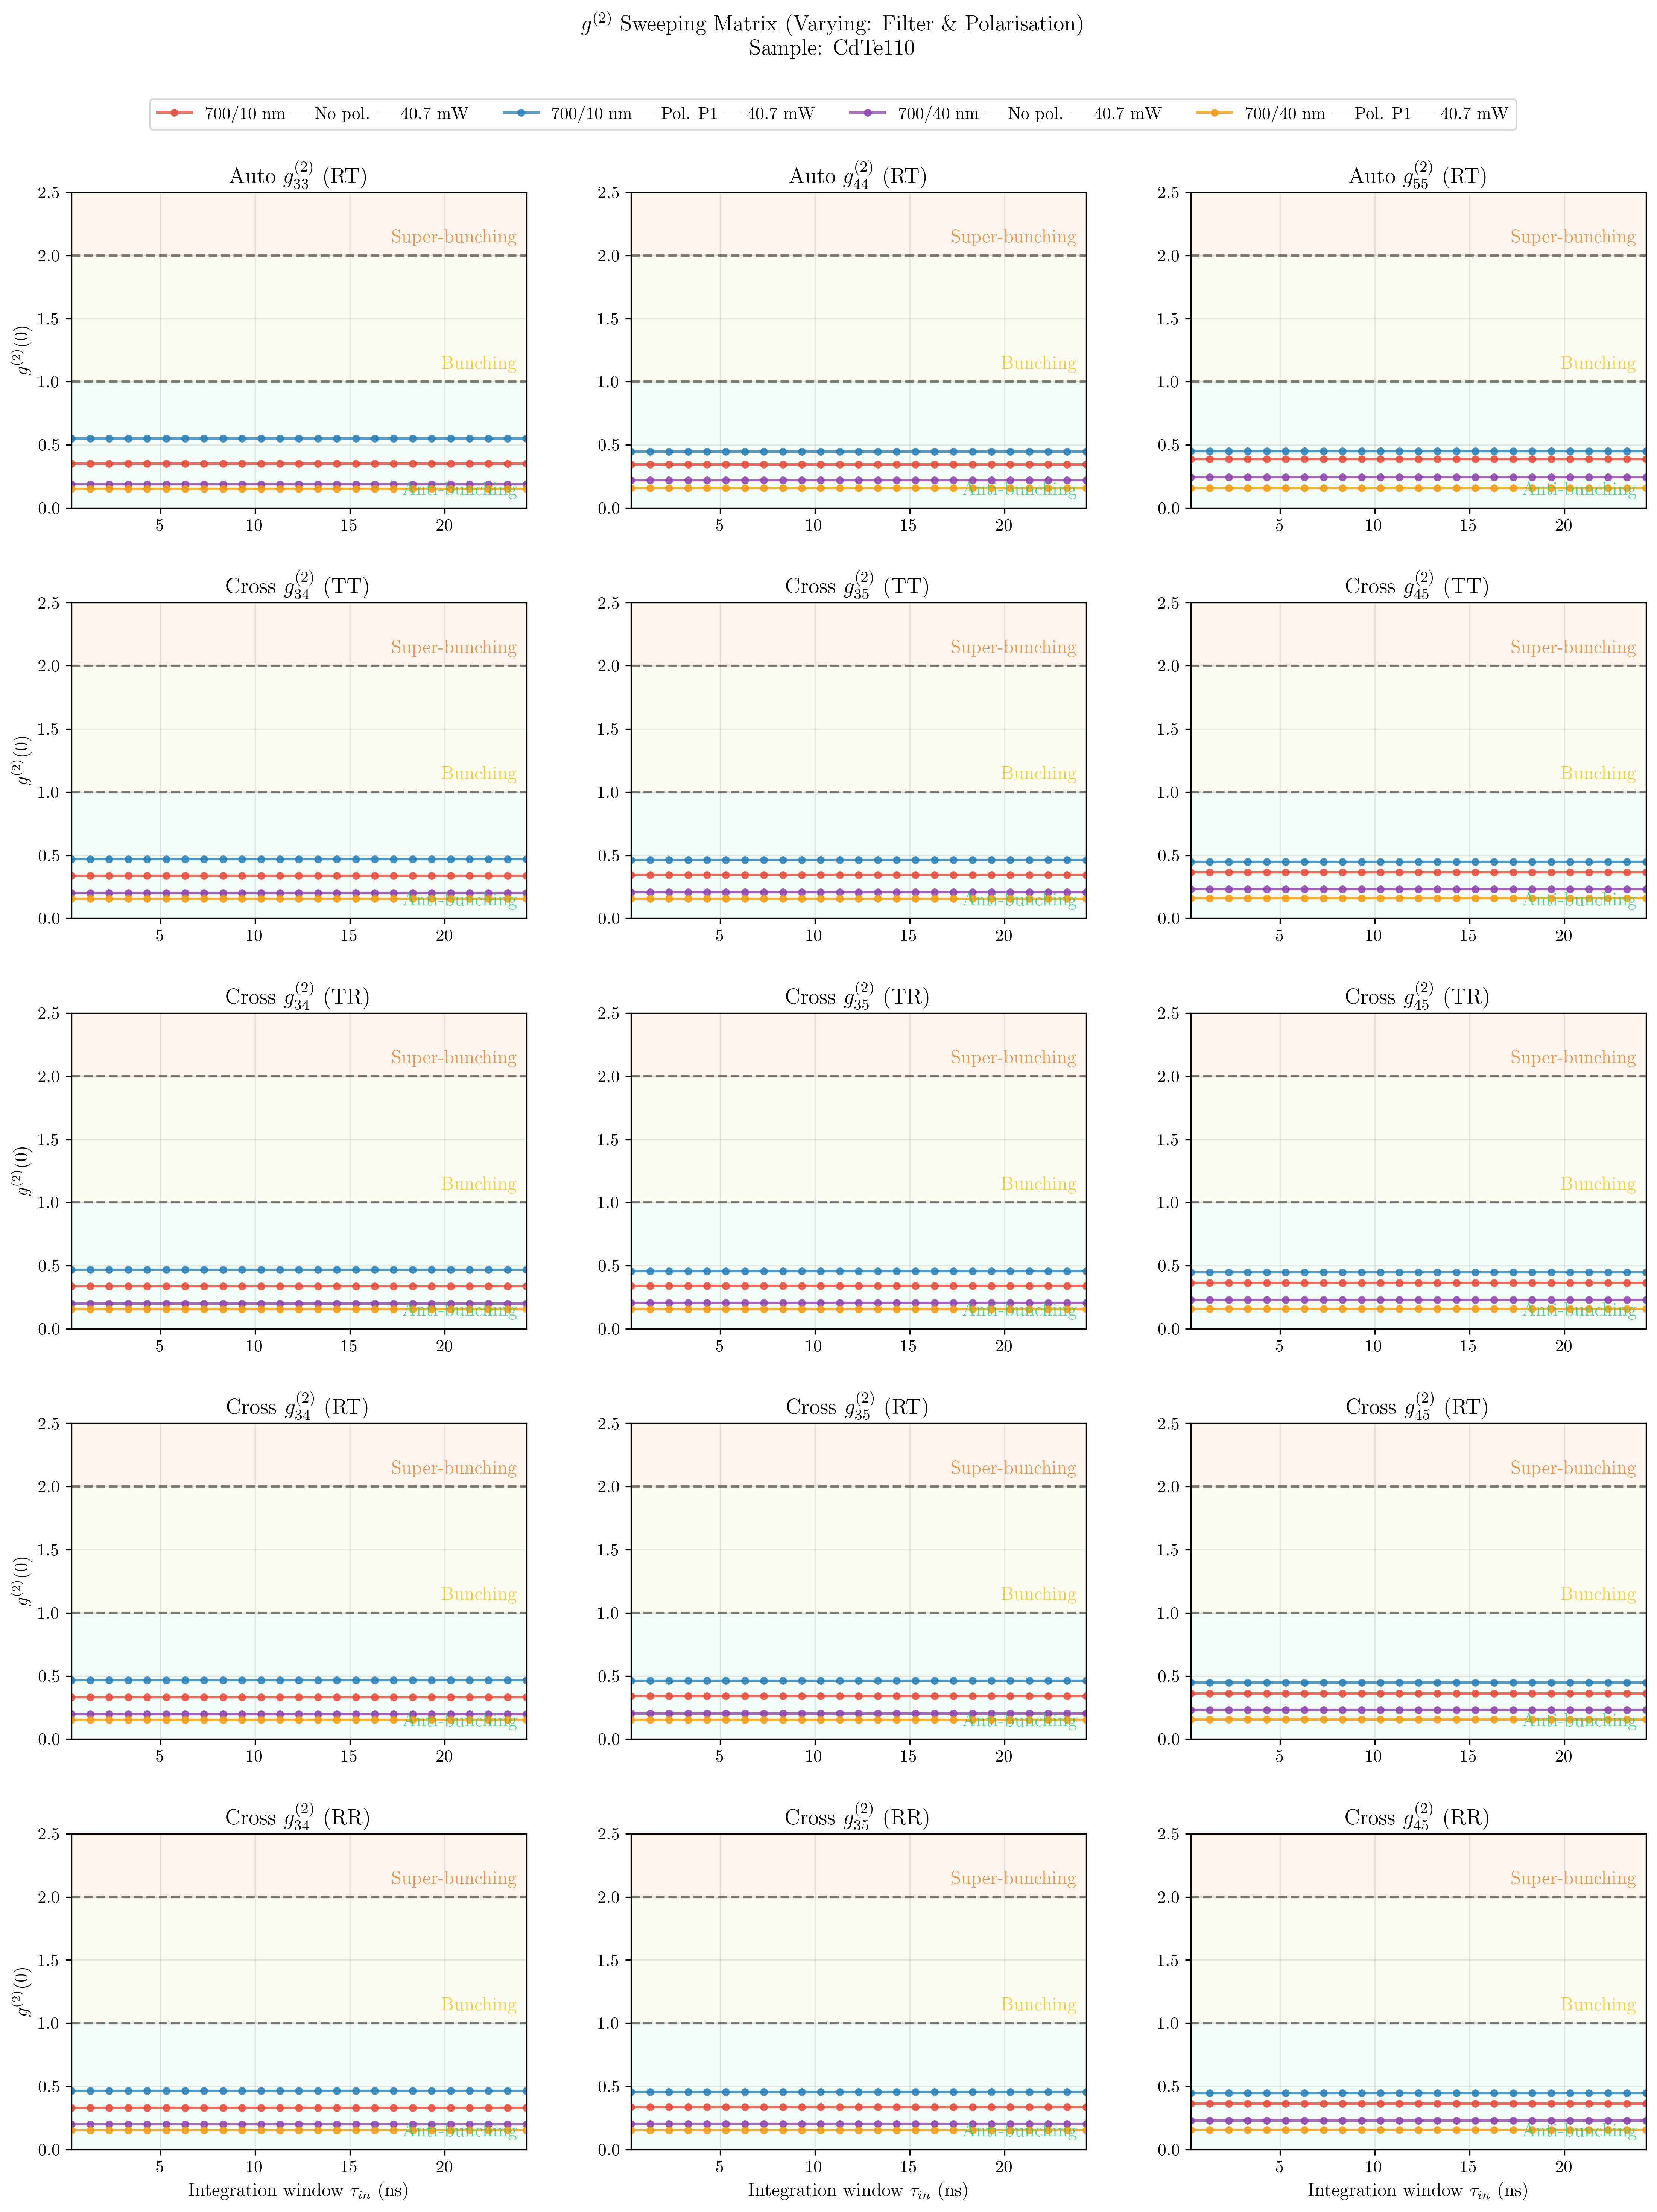

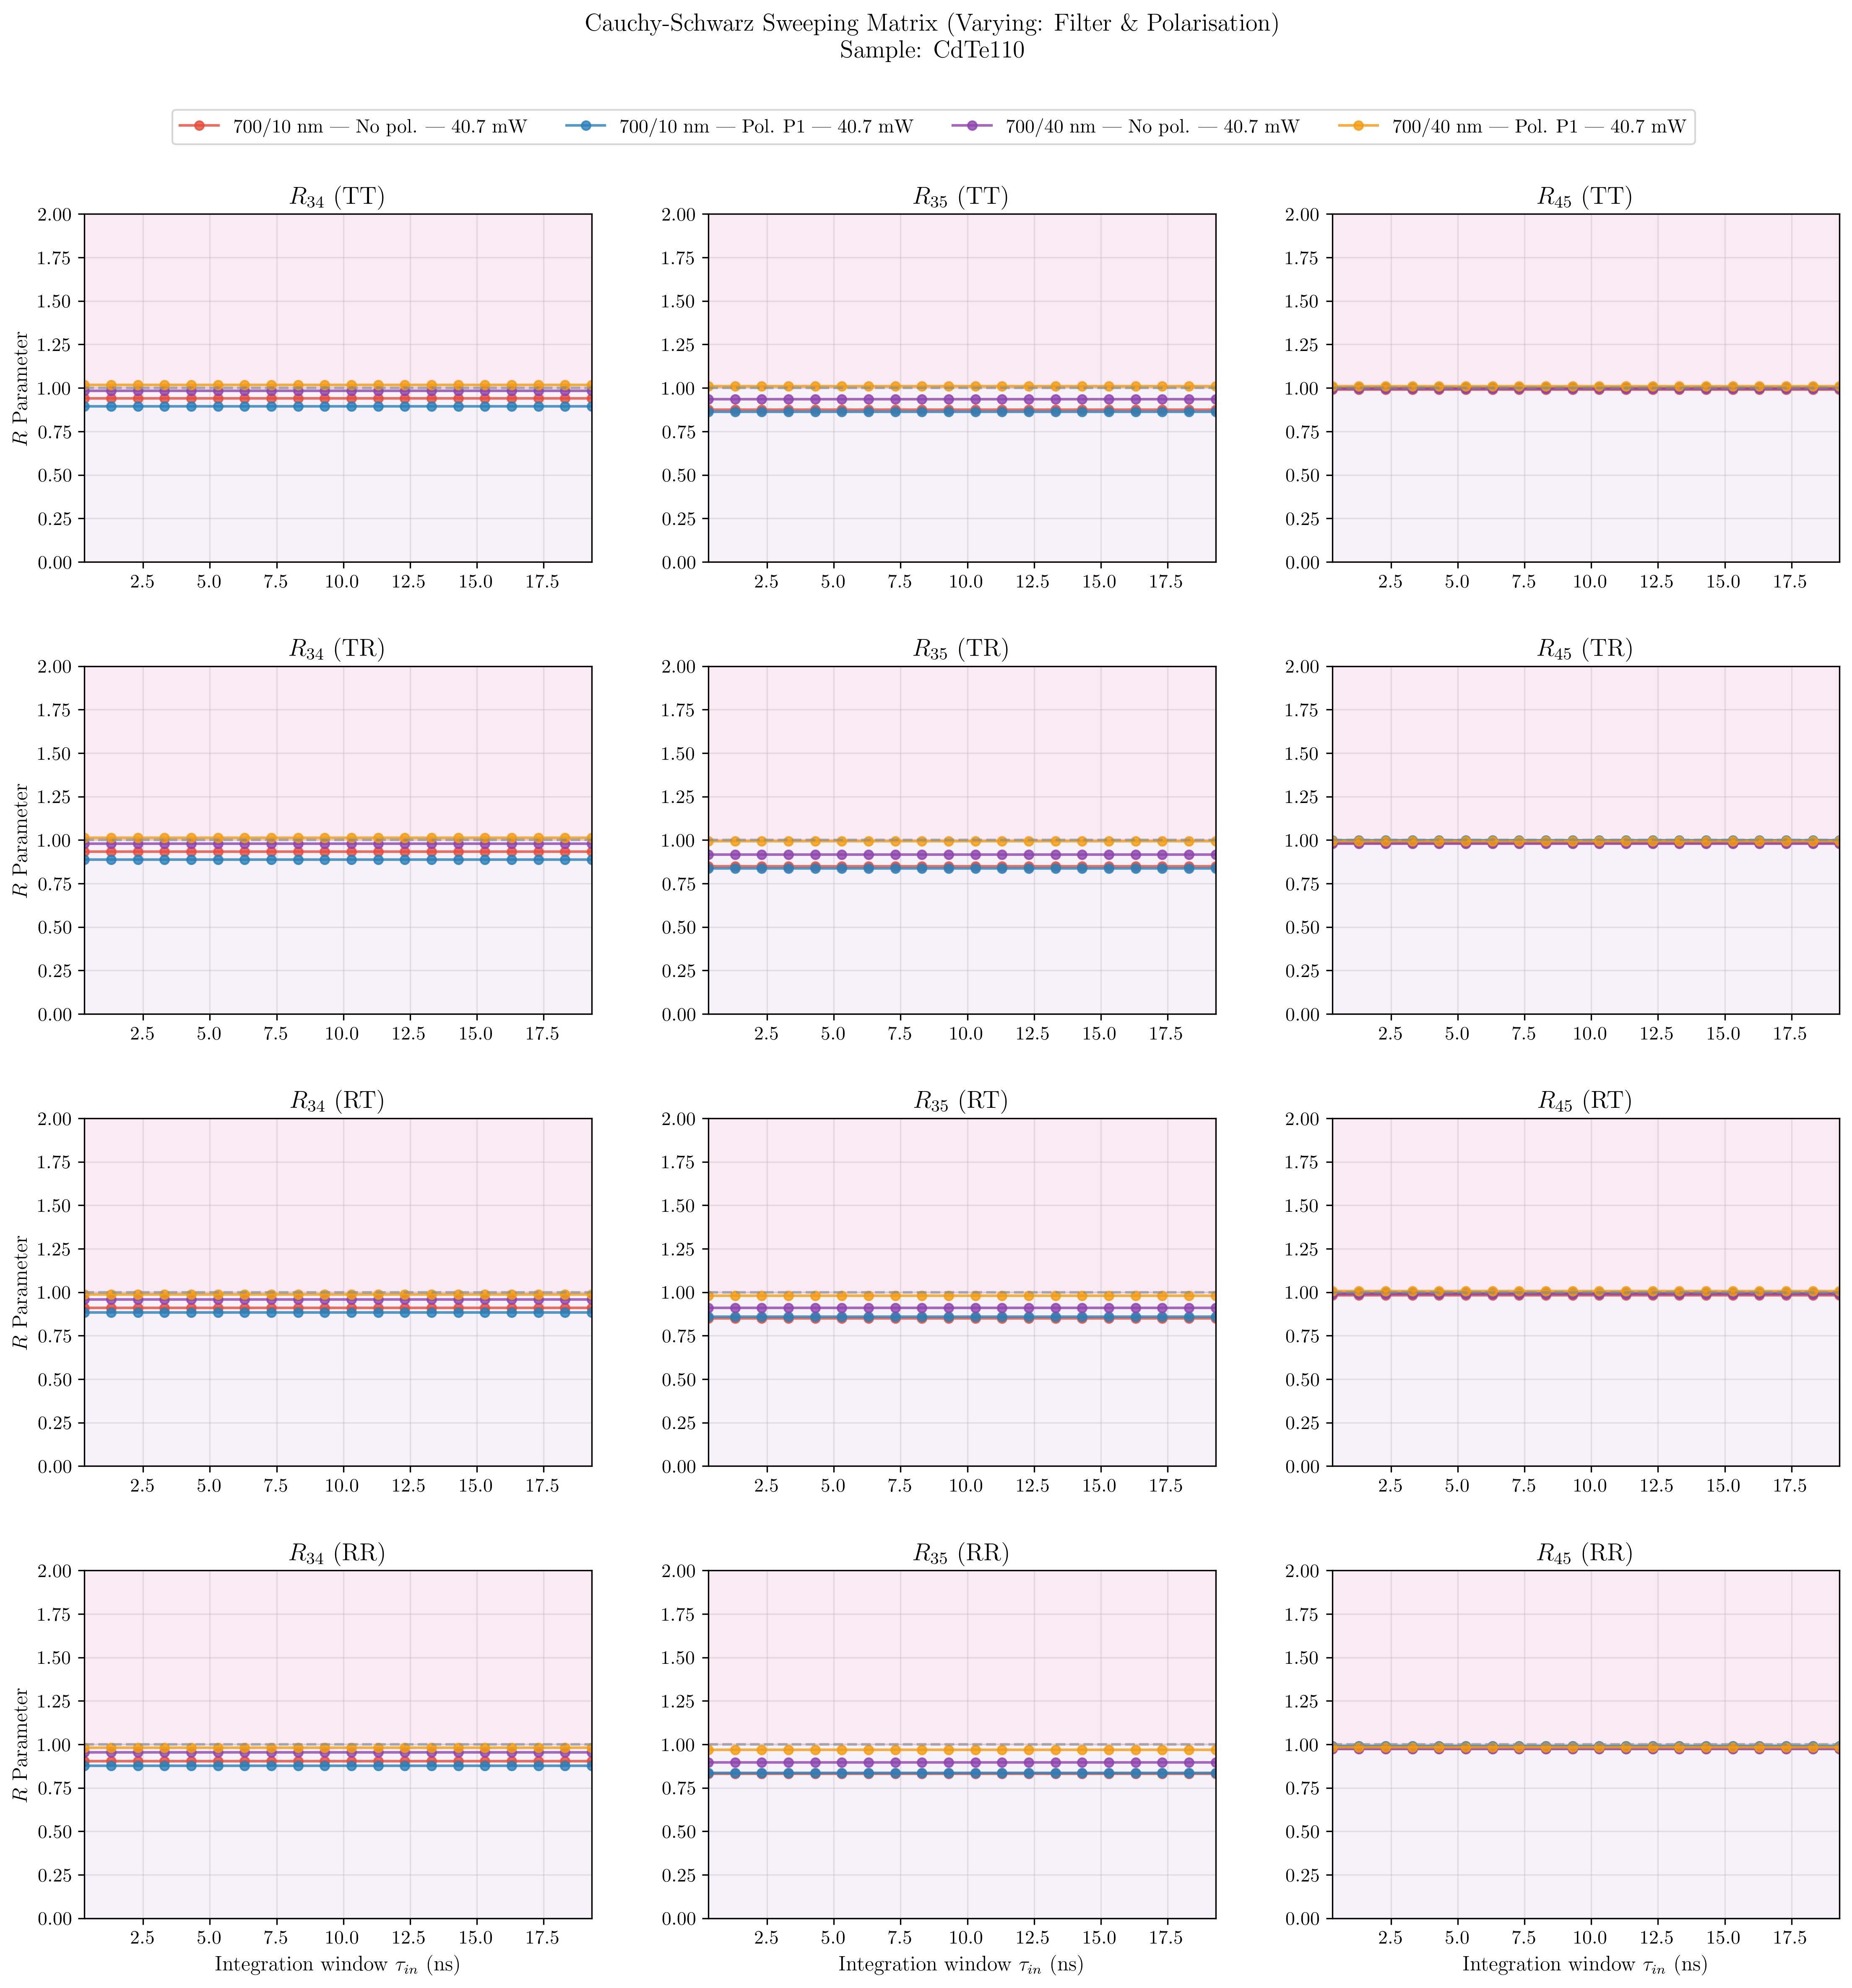

(<Figure size 5400x4800 with 12 Axes>,
 array([[<Axes: title={'center': '$R_{34}$ (TT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TT)'}>,
         <Axes: title={'center': '$R_{45}$ (TT)'}>],
        [<Axes: title={'center': '$R_{34}$ (TR)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TR)'}>,
         <Axes: title={'center': '$R_{45}$ (TR)'}>],
        [<Axes: title={'center': '$R_{34}$ (RT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RT)'}>,
         <Axes: title={'center': '$R_{45}$ (RT)'}>],
        [<Axes: title={'center': '$R_{34}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)', ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)'>,
         <Axes: title={'center': '$R_{45}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)'>]],
       dtype=object))

In [11]:
runs = [HBTMeasurement(p) for p in paths.values()]
comparator = GridVisualizer(runs, comparison_variable="Filter \\& Polarisation")

# Physical g2 and R, overlaid across the four runs.
comparator.plot_g2(methods=['direct'], tau_min=0.3, tau_max=25.0, step=1.0)
comparator.plot_R(methods=['direct'], tau_min=0.3, tau_max=20.0, step=1.0)

## Cheat-sheet

| Goal | Call | Reads from the pkl |
|---|---|---|
| Inspect the file | `run.describe()` | everything |
| Physical $g^{(2)}(0)$ *(default)* | `run.compute_g2_direct(c1, c2)` | `coincidences_twofold_physical`, `counts_physical`, `duration`, `rep_rate_hz` |
| Virtual $g^{(2)}$ (area ratio) | `run.compute_g2_delay(c1, c2, tau)` | `correlations_virtual` |
| Virtual heralded $g^{(2)}$ | `run.compute_g2_heralded(c1, c2, tau)` | `correlations_virtual`, `counts_virtual` |
| Cauchy–Schwarz $R$ | `run.compute_R_parameter(gc, ga, gb)` | (from the $g^{(2)}$ above) |
| Histogram trace | `run.get_correlation_trace(c1, c2)` | `correlations_virtual` (virtual only) |
| Figures | `GridVisualizer(run).plot_g2 / plot_R / plot_coherence` | all of the above |

**Golden rule:** physical conclusions come from `'direct'` (scalar physical coincidences);
the virtual histograms are diagnostics and are always labelled as such.